# Operational Oceanography Tutorial: Downloading Forecast Data from Copernicus Marine Service

**SAMOS Operational Oceanography — Practical Tutorial Monday 7. September**

In this tutorial you will:

1. Select a coastal region of South Africa to study.
2. Connect to the Copernicus Marine Service (CMEMS) and download **forecast** ocean data (temperature, salinity, and currents) for that region.
4. Load, inspect, and visualise the forecast data.
5. Complete some exercises to learn how to get and plot addiotional datasets.

> **Data source:** Copernicus Marine Service (CMEMS), Global Ocean Physics Analysis and Forecast product (`GLOBAL_ANALYSISFORECAST_PHY_001_024`).

## 1. Setup

We will use the official `copernicusmarine` Python toolbox to search for and download data, together with `xarray` for working with the downloaded NetCDF files, and `matplotlib` and `cartopy` for mapping.

Run the cell below once to install everything you need (you can comment it out afterwards).

If you use Colab instead of you local computer do File → Save a copy in Drive, right after opening the Colab link to make sure changes are saved.


In [1]:
# Run once per environment (e.g. once in your local conda/venv)
%pip install -q copernicusmarine xarray matplotlib cartopy netCDF4


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.5/130.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.9/376.9 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.1/225.1 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 7.4 MB/s eta 0:00:00


In [2]:
from datetime import datetime, timedelta, timezone

import copernicusmarine
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

import os
from getpass import getpass


## 2. Log in to Copernicus Marine Service

You need a free Copernicus Marine account to download data, I think you all signed up for it last week, if not sign up here:
[data.marine.copernicus.eu](https://data.marine.copernicus.eu).

Running the cell below will prompt you for your username and password the first time. Your credentials will need to be renentered in a new session.  Also checking that it works.


In [4]:
os.environ["CM_USERNAME"] = input("Copernicus Marine username: ")
os.environ["CM_PASSWORD"] = getpass("Copernicus Marine password: ")

copernicusmarine.login(
    username=os.environ["CM_USERNAME"],
    password=os.environ["CM_PASSWORD"],
    check_credentials_valid=True,
)


Copernicus Marine username: zmabaso
Copernicus Marine password: ··········


INFO - 2026-09-23T18:44:16Z - Checking if credentials are valid.
INFO:copernicusmarine:Checking if credentials are valid.
INFO - 2026-09-23T18:44:17Z - Valid credentials from input username and password.
INFO:copernicusmarine:Valid credentials from input username and password.


True

## 3. Select your region

Choose one of the preset regions around South Africa from the numbered menu below. Each region is defined by a bounding box (minimum/maximum longitude and latitude). After you pick one, its outline is drawn on a map so you can check it before downloading any data.

| Region | Characteristics |
|---|---|
| **Agulhas Bank (South Coast)** | Wide continental shelf south of Africa; strong shelf-edge frontal dynamics |
| **Benguela Upwelling (West Coast)** | Eastern boundary upwelling system; cold, productive, nutrient-rich water |
| **Agulhas Current Core (KZN to Port Elizabeth)** | Core of the fast, warm western boundary current |
| **Cape Town Coastal Waters** | Local coastal domain around Cape Town, influenced by both current systems |
| **Full South African (overview)** | Wide view of the whole South African coastline |

Feel free to add your own region to the `regions` dictionary if you want to study a different area.

Run the cell below, then type the **number** of the region you want at the prompt and press Enter.


Choose a region:

  1. Agulhas Bank (South Coast)
  2. Benguela Upwelling (West Coast)
  3. Agulhas Current Core (KZN to Port Elizabeth)
  4. Cape Town Coastal Waters
  5. Full South African (overview)

Enter a number (1-5): 2


/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


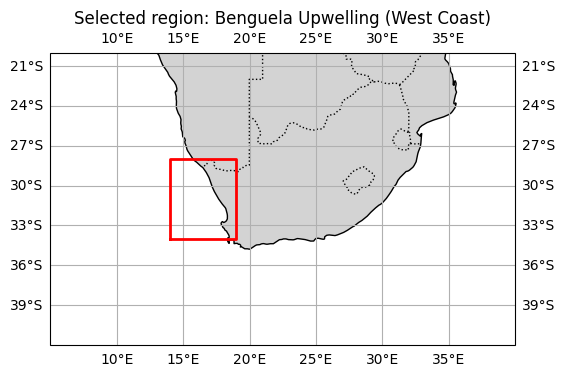

Bounding box -> lon: [14.0, 19.0], lat: [-34.0, -28.0]


In [5]:
regions = {
    "Agulhas Bank (South Coast)": {"lon_min": 18.0, "lon_max": 27.0, "lat_min": -37.0, "lat_max": -33.0},
    "Benguela Upwelling (West Coast)": {"lon_min": 14.0, "lon_max": 19.0, "lat_min": -34.0, "lat_max": -28.0},
    "Agulhas Current Core (KZN to Port Elizabeth)": {"lon_min": 29.0, "lon_max": 35.0, "lat_min": -32.0, "lat_max": -27.0},
    "Cape Town Coastal Waters": {"lon_min": 17.5, "lon_max": 19.5, "lat_min": -35.0, "lat_max": -33.5},
    "Full South African (overview)": {"lon_min": 10.0, "lon_max": 37.0, "lat_min": -40.0, "lat_max": -25.0},
}


def preview_region(region_name):
    bbox = regions[region_name]

    fig = plt.figure(figsize=(6, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([5, 40, -42, -20], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=":")
    ax.gridlines(draw_labels=True)

    ax.plot(
        [bbox["lon_min"], bbox["lon_max"], bbox["lon_max"], bbox["lon_min"], bbox["lon_min"]],
        [bbox["lat_min"], bbox["lat_min"], bbox["lat_max"], bbox["lat_max"], bbox["lat_min"]],
        color="red", linewidth=2, transform=ccrs.PlateCarree(),
    )
    ax.set_title(f"Selected region: {region_name}")
    plt.show()

    print(
        f"Bounding box -> lon: [{bbox['lon_min']}, {bbox['lon_max']}], "
        f"lat: [{bbox['lat_min']}, {bbox['lat_max']}]"
    )


region_names = list(regions.keys())
print("Choose a region:\n")
for i, name in enumerate(region_names, start=1):
    print(f"  {i}. {name}")

choice = input(f"\nEnter a number (1-{len(region_names)}): ").strip()
selected_name = region_names[int(choice) - 1]

REGION_SELECTED = dict(regions[selected_name])
REGION_SELECTED["name"] = selected_name

preview_region(selected_name)


> **Tip:** To change region later, just re-run the cell above and enter a different number — then re-run the download and plotting cells below.


## 4. Download forecast data from Copernicus Marine

We will download four variables for this tutorial:

- **`thetao`** — sea water potential temperature (°C)
- **`so`** — sea water salinity (PSU)
- **`uo`** — eastward sea water velocity (m/s)
- **`vo`** — northward sea water velocity (m/s)

from the **Global Ocean Physics Analysis and Forecast** product (`GLOBAL_ANALYSISFORECAST_PHY_001_024`), daily-mean resolution. This product is updated daily and provides forecasts 10 days into the future — `uo`/`vo` let us look directly at the Agulhas Current and other coastal currents.

This product is organised as **one dataset per variable (or variable group)**, so each is downloaded from its own dataset ID:

- `cmems_mod_glo_phy-thetao_anfc_0.083deg_P1D-m` → `thetao`
- `cmems_mod_glo_phy-so_anfc_0.083deg_P1D-m` → `so`
- `cmems_mod_glo_phy-cur_anfc_0.083deg_P1D-m` → `uo`, `vo` (bundled together)

To keep the download small and fast (useful on slower connections), we:
- request only the **surface layer** (`minimum_depth=0`, `maximum_depth=1`),
- request a **5-day forecast window** starting today,
- clip to the **bounding box** you selected above.

> Copernicus Marine occasionally restructures its catalogue and dataset IDs can change. If a dataset ID below stops working, run `copernicusmarine.describe(contains=["GLOBAL_ANALYSISFORECAST_PHY_001_024"])` to list the current dataset IDs and the variables each one contains, or check the "Data access" tab for this product at [data.marine.copernicus.eu](https://data.marine.copernicus.eu).


In [7]:
assert REGION_SELECTED, "Please select a region first (Section 3)."

# dataset_id -> variables provided by that dataset
DATASETS = {
    "cmems_mod_glo_phy-thetao_anfc_0.083deg_P1D-m": ["thetao"],
    "cmems_mod_glo_phy-so_anfc_0.083deg_P1D-m": ["so"],
    "cmems_mod_glo_phy-cur_anfc_0.083deg_P1D-m": ["uo", "vo"],
}

today = datetime.now(timezone.utc).date()
start_datetime = today.isoformat()
end_datetime = (today + timedelta(days=5)).isoformat()

output_dir = "cmems_data"
os.makedirs(output_dir, exist_ok=True)

region_tag = REGION_SELECTED["name"].replace(" ", "_").replace("(", "").replace(")", "")

print(f"Region:  {REGION_SELECTED['name']}")
print(f"Bbox:    lon [{REGION_SELECTED['lon_min']}, {REGION_SELECTED['lon_max']}], "
      f"lat [{REGION_SELECTED['lat_min']}, {REGION_SELECTED['lat_max']}]")
print(f"Forecast window: {start_datetime} to {end_datetime}")


Region:  Benguela Upwelling (West Coast)
Bbox:    lon [14.0, 19.0], lat [-34.0, -28.0]
Forecast window: 2026-09-23 to 2026-09-28


In [8]:
downloaded_files = []

for dataset_id, variables in DATASETS.items():
    variable_tag = "_".join(variables)
    output_filename = f"{region_tag}_{variable_tag}_forecast.nc"
    print(f"Downloading {variables} from {dataset_id} ...")

    copernicusmarine.subset(
        dataset_id=dataset_id,
        username=os.environ["CM_USERNAME"],
        password=os.environ["CM_PASSWORD"],
        variables=variables,
        minimum_longitude=REGION_SELECTED["lon_min"],
        maximum_longitude=REGION_SELECTED["lon_max"],
        minimum_latitude=REGION_SELECTED["lat_min"],
        maximum_latitude=REGION_SELECTED["lat_max"],
        start_datetime=start_datetime,
        end_datetime=end_datetime,
        minimum_depth=0,
        maximum_depth=1,
        output_directory=output_dir,
        output_filename=output_filename,
    )
    downloaded_files.append(os.path.join(output_dir, output_filename))

downloaded_files


INFO - 2026-09-23T18:45:22Z - Selected dataset version: "202406"
INFO:copernicusmarine:Selected dataset version: "202406"
INFO - 2026-09-23T18:45:22Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
WARNING - 2026-09-23T18:45:22Z - Some of your subset selection [0.0, 1.0] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 5727.9169921875]
INFO - 2026-09-23T18:45:28Z - Total size of the download: 117.74 KB.
INFO:copernicusmarine:Total size of the download: 117.74 KB.


INFO - 2026-09-23T18:45:31Z - Selected dataset version: "202406"
INFO:copernicusmarine:Selected dataset version: "202406"
INFO - 2026-09-23T18:45:31Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
WARNING - 2026-09-23T18:45:31Z - Some of your subset selection [0.0, 1.0] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 5727.9169921875]
INFO - 2026-09-23T18:45:35Z - Total size of the download: 117.74 KB.
INFO:copernicusmarine:Total size of the download: 117.74 KB.


INFO - 2026-09-23T18:45:38Z - Selected dataset version: "202406"
INFO:copernicusmarine:Selected dataset version: "202406"
INFO - 2026-09-23T18:45:38Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
WARNING - 2026-09-23T18:45:38Z - Some of your subset selection [0.0, 1.0] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 5727.9169921875]
INFO - 2026-09-23T18:45:43Z - Total size of the download: 222.16 KB.
INFO:copernicusmarine:Total size of the download: 222.16 KB.


['cmems_data/Benguela_Upwelling_West_Coast_thetao_forecast.nc',
 'cmems_data/Benguela_Upwelling_West_Coast_so_forecast.nc',
 'cmems_data/Benguela_Upwelling_West_Coast_uo_vo_forecast.nc']

## 5. Load and explore the forecast data

Each variable was downloaded into its own NetCDF file. We open both with `xarray` and merge them into a single dataset, then take a look at its structure: dimensions, coordinates, and variables.


In [9]:
# engine="netcdf4" avoids needing the optional h5py/h5netcdf packages
ds = xr.merge([xr.open_dataset(path, engine="netcdf4") for path in downloaded_files])
ds


<xarray.Dataset> Size: 428kB
Dimensions:    (time: 6, depth: 1, latitude: 73, longitude: 61)
Coordinates:
  * time       (time) datetime64[ns] 48B 2026-09-23 2026-09-24 ... 2026-09-28
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 292B -34.0 -33.92 -33.83 ... -28.08 -28.0
  * longitude  (longitude) float32 244B 14.0 14.08 14.17 ... 18.83 18.92 19.0
Data variables:
    thetao     (time, depth, latitude, longitude) float32 107kB ...
    so         (time, depth, latitude, longitude) float32 107kB ...
    uo         (time, depth, latitude, longitude) float32 107kB ...
    vo         (time, depth, latitude, longitude) float32 107kB ...
Attributes:
    Conventions:               CF-1.8
    area:                      Global
    contact:                   https://marine.copernicus.eu/contact
    credit:                    E.U. Copernicus Marine Service Information (CM...
    institution:               Mercator Ocean International
    licence:                   http://marine.copernicus.eu/services-portfolio...
    producer:                  CMEMS - Global Monitoring and Forecasting Centre
    references:                http://marine.copernicus.eu
    source:                    MOI GLO12
    title:                     daily mean fields from Global Ocean Physics An...
    copernicusmarine_version:  2.4.1

Take a moment to check:

- What are the dimensions of `thetao` and `so` (time, depth, latitude, longitude)?
- How many forecast days did you download?
- What are the units of each variable (check the variable's show/hide attributes symbol)?


In [10]:
for variable in ["thetao", "so", "uo", "vo"]:
    print(variable, "->", ds[variable].attrs)


thetao -> {'cell_methods': 'area: mean', 'long_name': 'Temperature', 'standard_name': 'sea_water_potential_temperature', 'unit_long': 'Degrees Celsius', 'units': 'degrees_C', 'valid_max': np.float32(40.0), 'valid_min': np.float32(-10.0)}
so -> {'cell_methods': 'area: mean', 'long_name': 'Salinity', 'standard_name': 'sea_water_salinity', 'unit_long': 'Practical Salinity Unit', 'units': '1e-3', 'valid_max': np.float32(50.0), 'valid_min': np.float32(0.0)}
uo -> {'cell_methods': 'area: mean', 'long_name': 'Eastward velocity', 'standard_name': 'eastward_sea_water_velocity', 'unit_long': 'Meters per second', 'units': 'm s-1', 'valid_max': np.float32(5.0), 'valid_min': np.float32(-5.0)}
vo -> {'cell_methods': 'area: mean', 'long_name': 'Northward velocity', 'standard_name': 'northward_sea_water_velocity', 'unit_long': 'Meters per second', 'units': 'm s-1', 'valid_max': np.float32(5.0), 'valid_min': np.float32(-5.0)}


## 6. Visualise the forecast

Let's map sea surface temperature, salinity, and current speed (with current direction as arrows) for the **first forecast day** (today) over your selected region.


/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


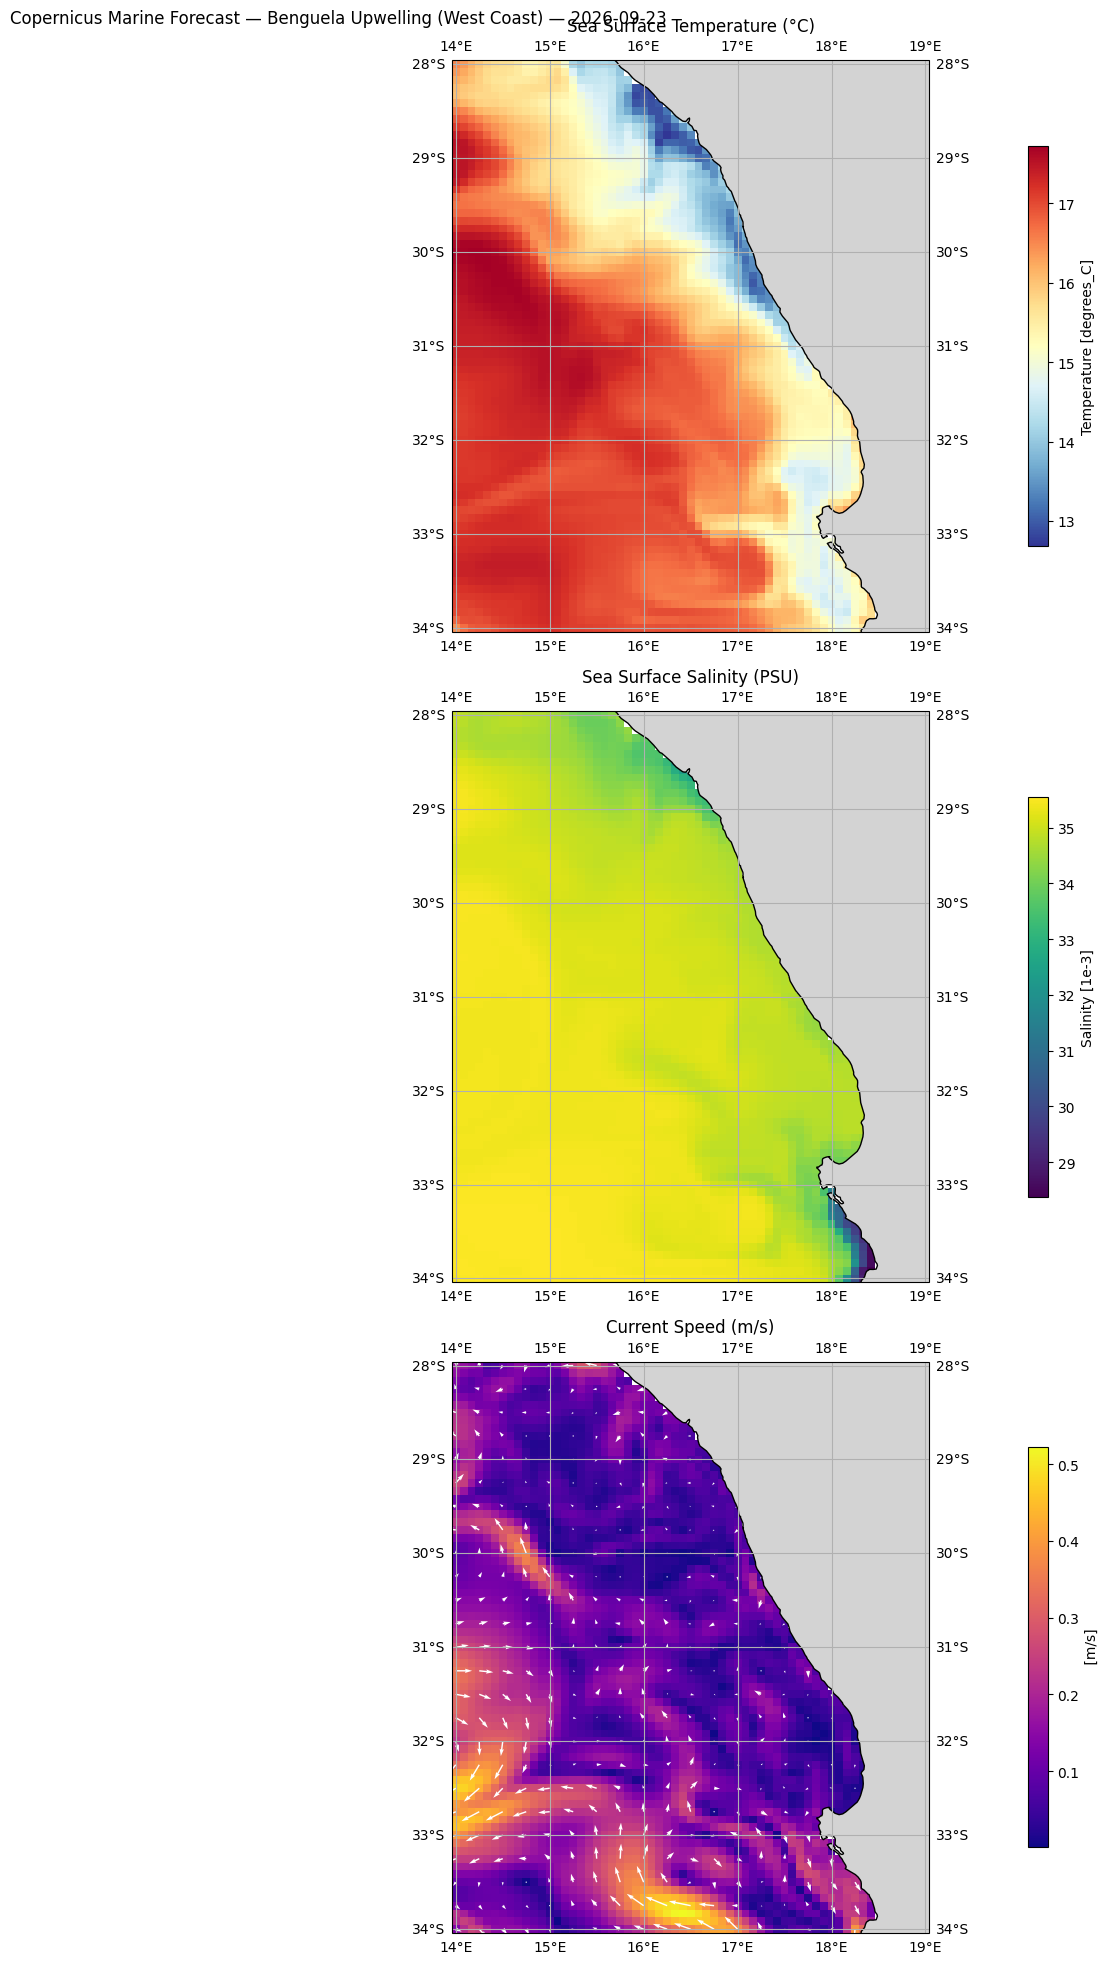

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(20, 20), subplot_kw={"projection": ccrs.PlateCarree()})

sst = ds["thetao"].isel(time=1, depth=0)
sss = ds["so"].isel(time=1, depth=0)
u = ds["uo"].isel(time=1, depth=0)
v = ds["vo"].isel(time=1, depth=0)
speed = np.sqrt(u ** 2 + v ** 2)
speed.attrs["units"] = "m/s"


panels = [
    (sst, "Sea Surface Temperature (°C)", "RdYlBu_r"),
    (sss, "Sea Surface Salinity (PSU)", "viridis"),
    (speed, "Current Speed (m/s)", "plasma"),
]

for ax, (data, title, cmap) in zip(axes, panels):
    data.plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(), cmap=cmap,
        cbar_kwargs={"shrink": 0.7},
    )
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
    ax.add_feature(cfeature.COASTLINE, zorder=2)
    ax.gridlines(draw_labels=True)
    ax.set_title(title)

# Overlay current direction arrows on the current-speed panel (subsampled so it stays readable)
skip = max(len(u.longitude) // 20, 1)
axes[2].quiver(
    u.longitude.values[::skip], u.latitude.values[::skip],
    u.values[::skip, ::skip], v.values[::skip, ::skip],
    transform=ccrs.PlateCarree(), color="white", scale=10, width=0.003,
)

plt.suptitle(f"Copernicus Marine Forecast — {REGION_SELECTED['name']} — {str(ds.time.values[0])[:10]}")
plt.tight_layout()
plt.show()


## 7. Exercises

Try the following on your own, reusing the code above:

1. **Compare regions.** Go back to Section 3, select a different region (e.g. switch from the Agulhas Bank to the Benguela Upwelling), re-run the download and plotting cells, and compare the temperature and salinity patterns. What differences do you notice, and why?
2. **Change the region.** Modify the extet of one of the 5 regions or add your own region as an option in the list above.
3. **Look further ahead.** Instead of `time=0`, plot the last day of the forecast (`time=-1`). How much does the temperature and salinity change over the 5-day forecast window?
4. **Look at a time series.** Pick a single location inside your region (a longitude/latitude pair), extract the forecast temperature at that point across all 5 days using `.sel(longitude=..., latitude=..., method="nearest")`, and plot it as a simple time series with `matplotlib`.
5. **Discussion.** Some applications of forecast were presented in the lecture today.  In your groups dicsuss potential applications of these forecasts.  
6. **Add a variable of your own.** The notebook currently downloads temperature, salinity, and currents. Pick another variable from the same product — for example `zos` (sea surface height, dataset `cmems_mod_glo_phy-ssh_anfc_0.083deg_P1D-m`) or `mlotst` (mixed layer depth, dataset `cmems_mod_glo_phy-mld_anfc_0.083deg_P1D-m`) — and extend Section 4 and Section 6 to download and plot it too. Use the [MyOceanViewer](https://data.marine.copernicus.eu/viewer/) that we used in the explored in the lecture today to find other variables.
Use the existing `thetao`/`so`/`uo`/`vo` code as your template: add an entry to the `DATASETS` dictionary, then add a new panel to the plotting figure.
7. **Compare 'time=0' to satelite observations** Based on what you learned last week, can you look for a suitabel dataset to compare the model fields to.
8. **Adding a biogeochemical variable** Try adding a variable from the biogeochemical forecast dataset: "GLOBAL_ANALYSISFORECAST_BGC_001_028"

## Useful references

- Copernicus Marine Service catalogue: <https://data.marine.copernicus.eu>
- `copernicusmarine` toolbox documentation: <https://help.marine.copernicus.eu/en/collections/9080063-copernicus-marine-toolbox>
- Product used in this tutorial: *Global Ocean Physics Analysis and Forecast* (`GLOBAL_ANALYSISFORECAST_PHY_001_024` and `GLOBAL_ANALYSISFORECAST_BGC_001_028`)


In [12]:
from datetime import datetime, timedelta, timezone
import copernicusmarine
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import os
from getpass import getpass

# Login (only needed once per session)
os.environ["CM_USERNAME"] = input("Copernicus Marine username: ")
os.environ["CM_PASSWORD"] = getpass("Copernicus Marine password: ")
copernicusmarine.login(
    username=os.environ["CM_USERNAME"],
    password=os.environ["CM_PASSWORD"],
    check_credentials_valid=True,
)

Copernicus Marine username: zmabaso
Copernicus Marine password: ··········


INFO - 2026-09-23T18:52:10Z - Checking if credentials are valid.
INFO:copernicusmarine:Checking if credentials are valid.
INFO - 2026-09-23T18:52:11Z - Valid credentials from input username and password.
INFO:copernicusmarine:Valid credentials from input username and password.


True

In [14]:
regions = {
    "Benguela": {"lon_min": 14.0, "lon_max": 19.0, "lat_min": -34.0, "lat_max": -28.0},
    "Agulhas":  {"lon_min": 29.0, "lon_max": 35.0, "lat_min": -32.0, "lat_max": -27.0},
}

DATASETS = {
    "cmems_mod_glo_phy-thetao_anfc_0.083deg_P1D-m": ["thetao"],
    "cmems_mod_glo_phy-so_anfc_0.083deg_P1D-m":    ["so"],
    "cmems_mod_glo_phy-cur_anfc_0.083deg_P1D-m":   ["uo", "vo"],
}

today = datetime.now(timezone.utc).date()
start_datetime = today.isoformat()
end_datetime = (today + timedelta(days=5)).isoformat()

os.makedirs("cmems_data", exist_ok=True)

for region_name, bbox in regions.items():
    for dataset_id, variables in DATASETS.items():
        var_tag = "_".join(variables)
        out_name = f"{region_name}_{var_tag}_forecast.nc"
        print(f"Downloading {region_name} — {variables} ...")
        copernicusmarine.subset(
            dataset_id=dataset_id,
            variables=variables,
            minimum_longitude=bbox["lon_min"], maximum_longitude=bbox["lon_max"],
            minimum_latitude=bbox["lat_min"],  maximum_latitude=bbox["lat_max"],
            start_datetime=start_datetime, end_datetime=end_datetime,
            minimum_depth=0, maximum_depth=1,
            output_directory="cmems_data", output_filename=out_name,
        )
print("All downloads complete.")

INFO - 2026-09-23T18:56:37Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register
INFO:copernicusmarine:Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username: zmabaso
Copernicus Marine password: ··········


INFO - 2026-09-23T18:56:54Z - Selected dataset version: "202406"
INFO:copernicusmarine:Selected dataset version: "202406"
INFO - 2026-09-23T18:56:54Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
WARNING - 2026-09-23T18:56:54Z - Some of your subset selection [0.0, 1.0] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 5727.9169921875]
INFO - 2026-09-23T18:56:59Z - Total size of the download: 117.74 KB.
INFO:copernicusmarine:Total size of the download: 117.74 KB.
INFO - 2026-09-23T18:56:59Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register
INFO:copernicusmarine:Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username: zmabaso
Copernicus Marine password: ··········


INFO - 2026-09-23T18:57:33Z - Selected dataset version: "202406"
INFO:copernicusmarine:Selected dataset version: "202406"
INFO - 2026-09-23T18:57:33Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
WARNING - 2026-09-23T18:57:33Z - Some of your subset selection [0.0, 1.0] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 5727.9169921875]
INFO - 2026-09-23T18:57:37Z - Total size of the download: 117.74 KB.
INFO:copernicusmarine:Total size of the download: 117.74 KB.
INFO - 2026-09-23T18:57:37Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register
INFO:copernicusmarine:Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


...

Copernicus Marine username: zmabaso
Copernicus Marine password: ··········


INFO - 2026-09-23T18:58:57Z - Selected dataset version: "202406"
INFO:copernicusmarine:Selected dataset version: "202406"
INFO - 2026-09-23T18:58:57Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
WARNING - 2026-09-23T18:58:57Z - Some of your subset selection [0.0, 1.0] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 5727.9169921875]
INFO - 2026-09-23T18:59:01Z - Total size of the download: 117.74 KB.
INFO:copernicusmarine:Total size of the download: 117.74 KB.
INFO - 2026-09-23T18:59:01Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register
INFO:copernicusmarine:Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username: zmabaso
Copernicus Marine password: ··········


INFO - 2026-09-23T18:59:30Z - Selected dataset version: "202406"
INFO:copernicusmarine:Selected dataset version: "202406"
INFO - 2026-09-23T18:59:30Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
WARNING - 2026-09-23T18:59:30Z - Some of your subset selection [0.0, 1.0] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 5727.9169921875]
INFO - 2026-09-23T18:59:34Z - Total size of the download: 222.16 KB.
INFO:copernicusmarine:Total size of the download: 222.16 KB.


All downloads complete.


In [15]:
benguela_files = [
    "cmems_data/Benguela_thetao_forecast.nc",
    "cmems_data/Benguela_so_forecast.nc",
    "cmems_data/Benguela_uo_vo_forecast.nc",
]
ds = xr.merge([xr.open_dataset(f, engine="netcdf4") for f in benguela_files])
print(ds)

<xarray.Dataset> Size: 428kB
Dimensions:    (time: 6, depth: 1, latitude: 73, longitude: 61)
Coordinates:
  * time       (time) datetime64[ns] 48B 2026-09-23 2026-09-24 ... 2026-09-28
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 292B -34.0 -33.92 -33.83 ... -28.08 -28.0
  * longitude  (longitude) float32 244B 14.0 14.08 14.17 ... 18.83 18.92 19.0
Data variables:
    thetao     (time, depth, latitude, longitude) float32 107kB ...
    so         (time, depth, latitude, longitude) float32 107kB ...
    uo         (time, depth, latitude, longitude) float32 107kB ...
    vo         (time, depth, latitude, longitude) float32 107kB ...
Attributes:
    Conventions:               CF-1.8
    area:                      Global
    contact:                   https://marine.copernicus.eu/contact
    credit:                    E.U. Copernicus Marine Service Information (CM...
    institution:               Mercator Ocean International
    licence:                   http:/

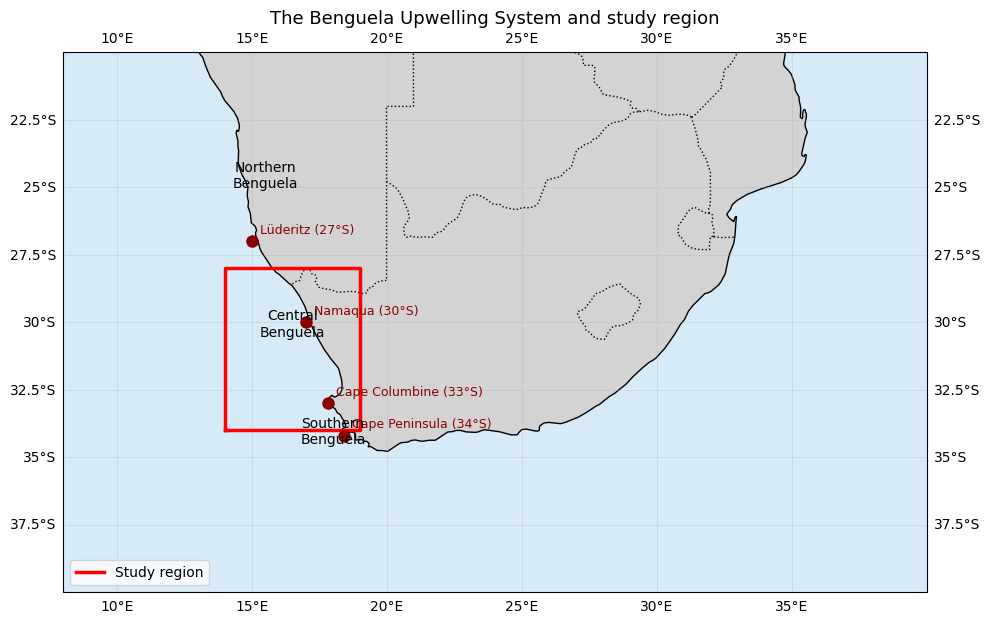

In [18]:
# ============================================================
# FIGURE 1 — Study Area: The Benguela Upwelling System
# ============================================================
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Full SW African domain
ax.set_extent([8, 40, -40, -20], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE, linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.5)

# Bathymetry-style shading is not available here, but we can shade the ocean
ax.add_feature(cfeature.OCEAN, facecolor="#d6eaf8", zorder=0)

# Benguela study box
ax.plot(
    [14, 19, 19, 14, 14], [-34, -34, -28, -28, -34],
    color="red", linewidth=2.5, transform=ccrs.PlateCarree(), label="Study region"
)

# Major upwelling cells (approx. positions)
cells = {
    "Lüderitz (27°S)": (15.0, -27.0),
    "Namaqua (30°S)":  (17.0, -30.0),
    "Cape Columbine (33°S)": (17.8, -33.0),
    "Cape Peninsula (34°S)": (18.4, -34.2),
}
for name, (lon, lat) in cells.items():
    ax.plot(lon, lat, marker="o", color="darkred", markersize=8,
            transform=ccrs.PlateCarree())
    ax.text(lon + 0.3, lat + 0.3, name, fontsize=9,
            transform=ccrs.PlateCarree(), color="darkred")

# Sub-region labels
ax.text(15.5, -25.0, "Northern\nBenguela", fontsize=10, ha="center",
        transform=ccrs.PlateCarree())
ax.text(16.5, -30.5, "Central\nBenguela", fontsize=10, ha="center",
        transform=ccrs.PlateCarree())
ax.text(18.0, -34.5, "Southern\nBenguela", fontsize=10, ha="center",
        transform=ccrs.PlateCarree())

ax.set_title("The Benguela Upwelling System and study region", fontsize=13)
ax.legend(loc="lower left")
plt.tight_layout()
plt.savefig("fig1_study_area.png", dpi=200, bbox_inches="tight")
plt.show()

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


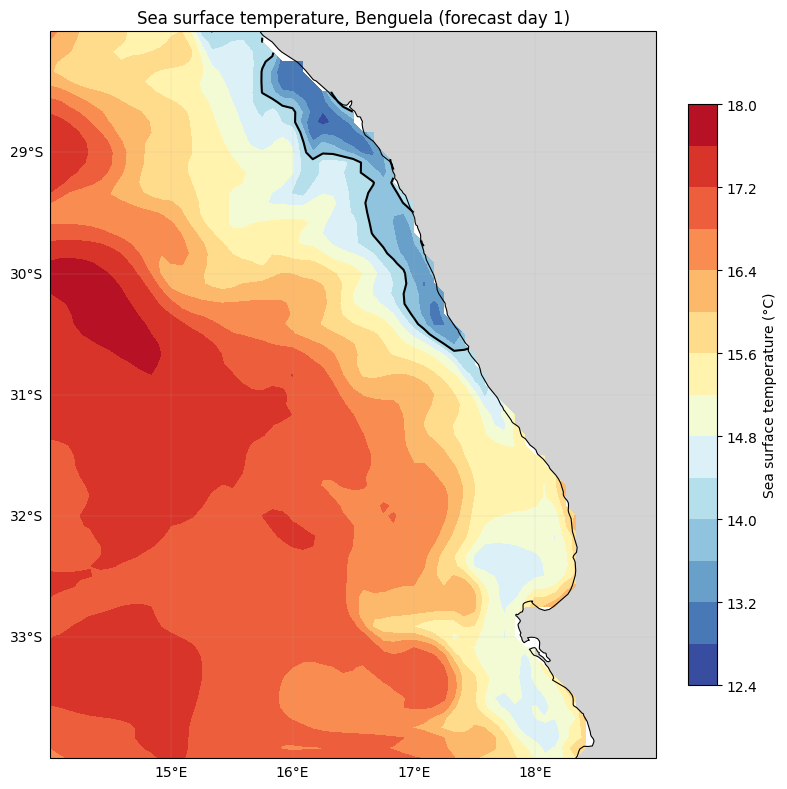

In [19]:

# ============================================================
# FIGURE 2 — SST snapshot (upwelling signature)
# ============================================================
sst = ds["thetao"].isel(time=1, depth=0)   # time=1 → tomorrow's forecast

fig = plt.figure(figsize=(11, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([14, 19, -34, -28], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)

cf = ax.contourf(sst.longitude, sst.latitude, sst,
                 levels=15, cmap="RdYlBu_r", transform=ccrs.PlateCarree())
cb = plt.colorbar(cf, ax=ax, orientation="vertical", pad=0.03, shrink=0.8)
cb.set_label("Sea surface temperature (°C)")

# Overlay the 14 °C contour to highlight the cold upwelled band
ax.contour(sst.longitude, sst.latitude, sst, levels=[14],
           colors="black", linewidths=1.5, transform=ccrs.PlateCarree())

ax.set_title("Sea surface temperature, Benguela (forecast day 1)", fontsize=12)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4)
gl.top_labels = False; gl.right_labels = False
plt.tight_layout()
plt.savefig("fig2_sst.png", dpi=200, bbox_inches="tight")
plt.show()

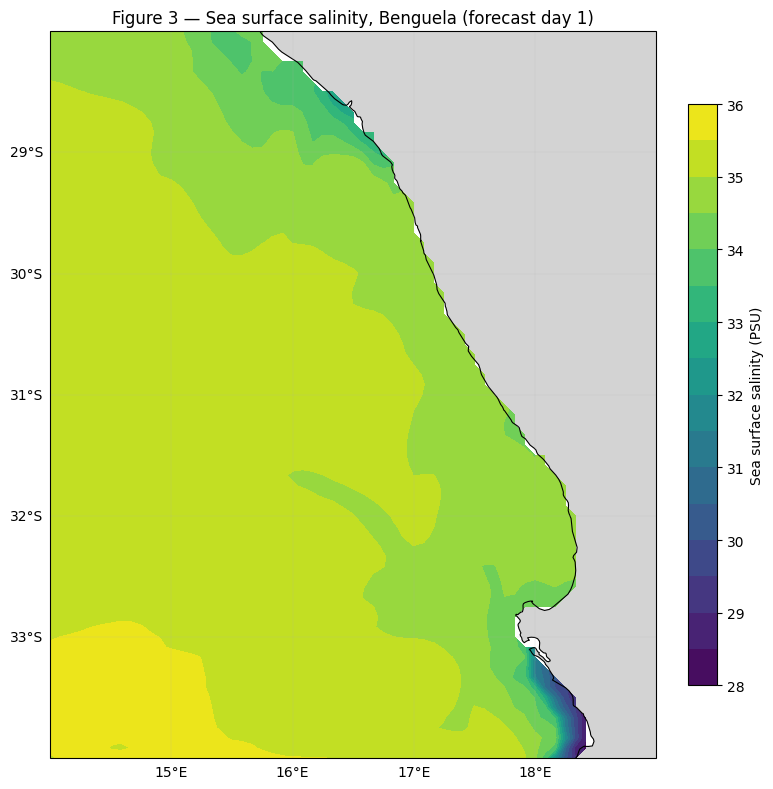

In [20]:
# ============================================================
# FIGURE 3 — Sea surface salinity
# ============================================================
sss = ds["so"].isel(time=1, depth=0)

fig = plt.figure(figsize=(11, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([14, 19, -34, -28], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)

cf = ax.contourf(sss.longitude, sss.latitude, sss,
                 levels=15, cmap="viridis", transform=ccrs.PlateCarree())
cb = plt.colorbar(cf, ax=ax, orientation="vertical", pad=0.03, shrink=0.8)
cb.set_label("Sea surface salinity (PSU)")

ax.set_title("Figure 3 — Sea surface salinity, Benguela (forecast day 1)", fontsize=12)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4)
gl.top_labels = False; gl.right_labels = False
plt.tight_layout()
plt.savefig("fig3_sss.png", dpi=200, bbox_inches="tight")
plt.show()

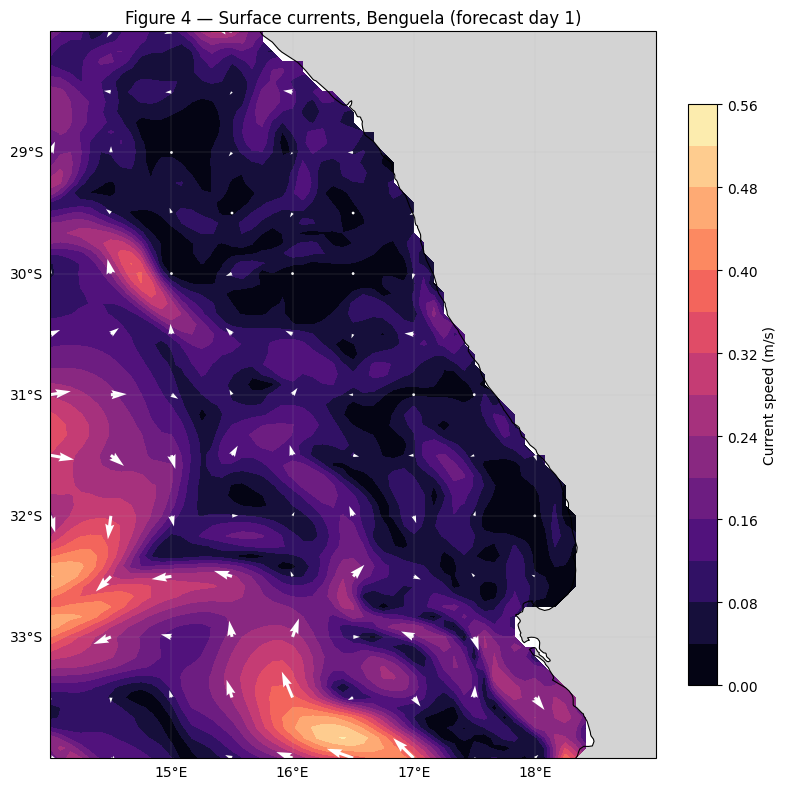

In [21]:
# ============================================================
# FIGURE 4 — Surface current speed + vectors
# ============================================================
u = ds["uo"].isel(time=1, depth=0)
v = ds["vo"].isel(time=1, depth=0)
speed = np.sqrt(u**2 + v**2)

fig = plt.figure(figsize=(11, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([14, 19, -34, -28], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)

cf = ax.contourf(speed.longitude, speed.latitude, speed,
                 levels=15, cmap="magma", transform=ccrs.PlateCarree())
cb = plt.colorbar(cf, ax=ax, orientation="vertical", pad=0.03, shrink=0.8)
cb.set_label("Current speed (m/s)")

# Subsample arrows for clarity
step = 6
ax.quiver(u.longitude[::step], u.latitude[::step],
          u[::step, ::step], v[::step, ::step],
          scale=8, color="white", transform=ccrs.PlateCarree())

ax.set_title("Figure 4 — Surface currents, Benguela (forecast day 1)", fontsize=12)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4)
gl.top_labels = False; gl.right_labels = False
plt.tight_layout()
plt.savefig("fig4_currents.png", dpi=200, bbox_inches="tight")
plt.show()

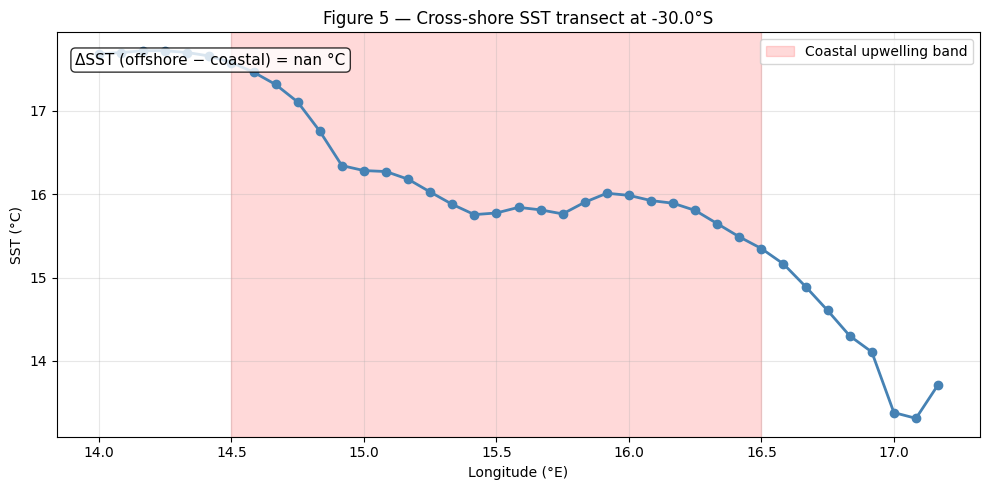

In [22]:
# ============================================================
# FIGURE 5 — Cross-shore SST transect (upwelling index)
# ============================================================
lat_target = -30.0
transect = ds["thetao"].isel(time=1, depth=0).sel(latitude=lat_target, method="nearest")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(transect.longitude, transect, marker="o", color="steelblue", linewidth=2)
ax.axvspan(14.5, 16.5, color="red", alpha=0.15, label="Coastal upwelling band")
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("SST (°C)")
ax.set_title(f"Figure 5 — Cross-shore SST transect at {lat_target}°S")
ax.grid(alpha=0.3); ax.legend()

# Compute the gradient
coastal = float(transect.sel(longitude=slice(14.5, 16.0)).mean())
offshore = float(transect.sel(longitude=slice(17.5, 18.5)).mean())
gradient = offshore - coastal
ax.text(0.02, 0.95, f"ΔSST (offshore − coastal) = {gradient:.2f} °C",
        transform=ax.transAxes, fontsize=11, va="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.savefig("fig5_transect.png", dpi=200, bbox_inches="tight")
plt.show()

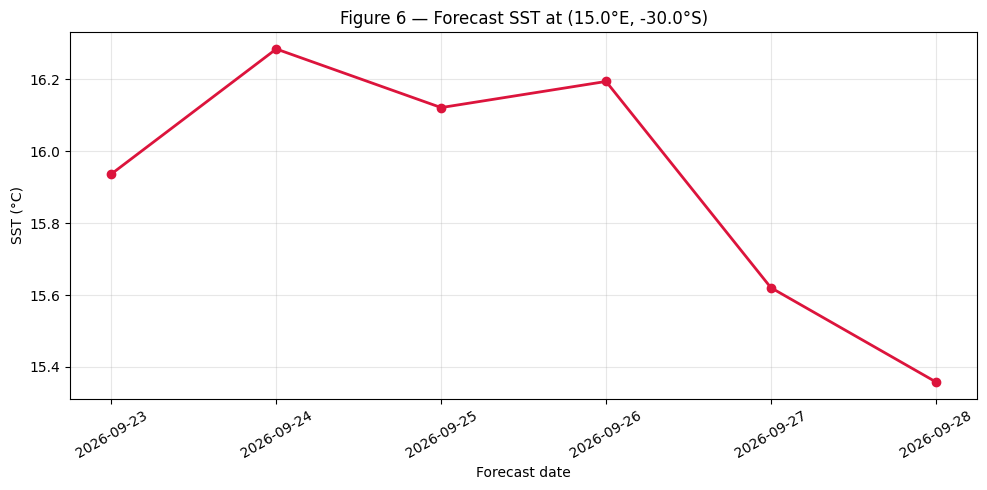

In [23]:
# ============================================================
# FIGURE 6 — Forecast time series at a coastal point
# ============================================================
lon_pt, lat_pt = 15.0, -30.0
ts = ds["thetao"].isel(depth=0).sel(longitude=lon_pt, latitude=lat_pt, method="nearest")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ts.time, ts, marker="o", color="crimson", linewidth=2)
ax.set_xlabel("Forecast date")
ax.set_ylabel("SST (°C)")
ax.set_title(f"Figure 6 — Forecast SST at ({lon_pt}°E, {lat_pt}°S)")
ax.grid(alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("fig6_timeseries.png", dpi=200, bbox_inches="tight")
plt.show()

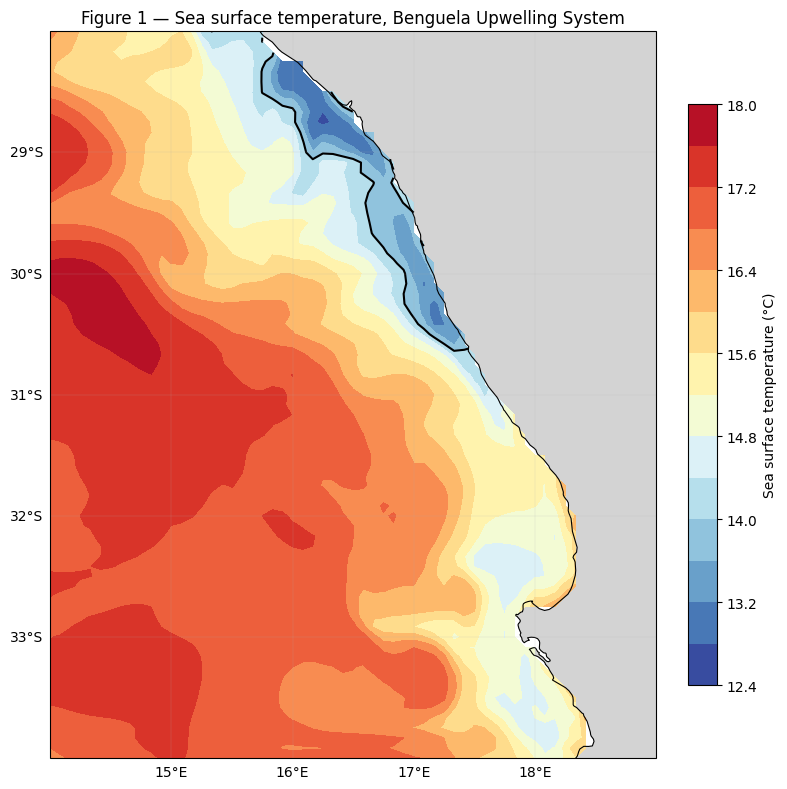

In [24]:
# ============================================================
# FIGURE 1 — Sea surface temperature, Benguela
# ============================================================
fig = plt.figure(figsize=(11, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([14, 19, -34, -28], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)

cf = ax.contourf(sst.longitude, sst.latitude, sst,
                 levels=15, cmap="RdYlBu_r", transform=ccrs.PlateCarree())
cb = plt.colorbar(cf, ax=ax, pad=0.03, shrink=0.8)
cb.set_label("Sea surface temperature (°C)")

# Highlight the cold upwelled band with a 14 °C contour
ax.contour(sst.longitude, sst.latitude, sst, levels=[14],
           colors="black", linewidths=1.5, transform=ccrs.PlateCarree())

ax.set_title("Figure 1 — Sea surface temperature, Benguela Upwelling System", fontsize=12)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4)
gl.top_labels = False; gl.right_labels = False
plt.tight_layout()
plt.savefig("fig1_benguela_sst.png", dpi=200, bbox_inches="tight")
plt.show()

In [27]:
bbox = {"lon_min": 14.0, "lon_max": 19.0, "lat_min": -34.0, "lat_max": -28.0}

today = datetime.now(timezone.utc).date()
start_datetime = today.isoformat()
end_datetime = (today + timedelta(days=5)).isoformat()

os.makedirs("cmems_data", exist_ok=True)

# --- Physics: temperature, salinity, currents ---
physics_datasets = {
    "cmems_mod_glo_phy-thetao_anfc_0.083deg_P1D-m": ["thetao"],
    "cmems_mod_glo_phy-so_anfc_0.083deg_P1D-m":    ["so"],
    "cmems_mod_glo_phy-cur_anfc_0.083deg_P1D-m":   ["uo", "vo"],
}
for dataset_id, variables in physics_datasets.items():
    var_tag = "_".join(variables)
    copernicusmarine.subset(
        dataset_id=dataset_id,
        variables=variables,
        minimum_longitude=bbox["lon_min"], maximum_longitude=bbox["lon_max"],
        minimum_latitude=bbox["lat_min"],  maximum_latitude=bbox["lat_max"],
        start_datetime=start_datetime, end_datetime=end_datetime,
        minimum_depth=0, maximum_depth=1,
        output_directory="cmems_data",
        output_filename=f"Benguela_{var_tag}_forecast.nc",
    )

# --- Biogeochemistry: chlorophyll ---
copernicusmarine.subset(
    dataset_id="cmems_mod_glo_bgc-pft_anfc_0.25deg_P1D-m",
    variables=["chl"],
    minimum_longitude=bbox["lon_min"], maximum_longitude=bbox["lon_max"],
    minimum_latitude=bbox["lat_min"],  maximum_latitude=bbox["lat_max"],
    start_datetime=start_datetime, end_datetime=end_datetime,
    minimum_depth=0, maximum_depth=1,
    output_directory="cmems_data",
    output_filename="Benguela_chl_forecast.nc",
)

# --- Load everything ---
ds = xr.merge([
    xr.open_dataset("cmems_data/Benguela_thetao_forecast.nc", engine="netcdf4"),
    xr.open_dataset("cmems_data/Benguela_so_forecast.nc", engine="netcdf4"),
    xr.open_dataset("cmems_data/Benguela_uo_vo_forecast.nc", engine="netcdf4"),
])
ds_chl = xr.open_dataset("cmems_data/Benguela_chl_forecast.nc", engine="netcdf4")

# Common fields
sst = ds["thetao"].isel(time=1, depth=0)
sss = ds["so"].isel(time=1, depth=0)
u   = ds["uo"].isel(time=1, depth=0)
v   = ds["vo"].isel(time=1, depth=0)
chl = ds_chl["chl"].isel(time=1, depth=0)
print("Data loaded.")

INFO - 2026-09-23T19:28:27Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register
INFO:copernicusmarine:Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username: zmabaso
Copernicus Marine password: ··········


INFO - 2026-09-23T19:28:52Z - Selected dataset version: "202406"
INFO:copernicusmarine:Selected dataset version: "202406"
INFO - 2026-09-23T19:28:52Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
WARNING - 2026-09-23T19:28:52Z - Some of your subset selection [0.0, 1.0] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 5727.9169921875]
INFO - 2026-09-23T19:28:56Z - Total size of the download: 117.74 KB.
INFO:copernicusmarine:Total size of the download: 117.74 KB.
INFO - 2026-09-23T19:28:56Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register
INFO:copernicusmarine:Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username: zmabaso
Copernicus Marine password: ··········


INFO - 2026-09-23T19:29:17Z - Selected dataset version: "202406"
INFO:copernicusmarine:Selected dataset version: "202406"
INFO - 2026-09-23T19:29:17Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
WARNING - 2026-09-23T19:29:17Z - Some of your subset selection [0.0, 1.0] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 5727.9169921875]
INFO - 2026-09-23T19:29:22Z - Total size of the download: 117.74 KB.
INFO:copernicusmarine:Total size of the download: 117.74 KB.
INFO - 2026-09-23T19:29:22Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register
INFO:copernicusmarine:Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username: zmabaso
Copernicus Marine password: ··········


INFO - 2026-09-23T19:29:43Z - Selected dataset version: "202406"
INFO:copernicusmarine:Selected dataset version: "202406"
INFO - 2026-09-23T19:29:43Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
WARNING - 2026-09-23T19:29:43Z - Some of your subset selection [0.0, 1.0] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 5727.9169921875]
INFO - 2026-09-23T19:29:49Z - Total size of the download: 222.16 KB.
INFO:copernicusmarine:Total size of the download: 222.16 KB.
INFO - 2026-09-23T19:29:49Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register
INFO:copernicusmarine:Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username: zmabaso
Copernicus Marine password: ··········


INFO - 2026-09-23T19:30:09Z - Selected dataset version: "202311"
INFO:copernicusmarine:Selected dataset version: "202311"
INFO - 2026-09-23T19:30:09Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
WARNING - 2026-09-23T19:30:09Z - Some of your subset selection [0.0, 1.0] for the depth dimension exceed the dataset coordinates [0.4940253794193268, 5727.91650390625]
INFO - 2026-09-23T19:30:13Z - Total size of the download: 25.62 KB.
INFO:copernicusmarine:Total size of the download: 25.62 KB.


Data loaded.


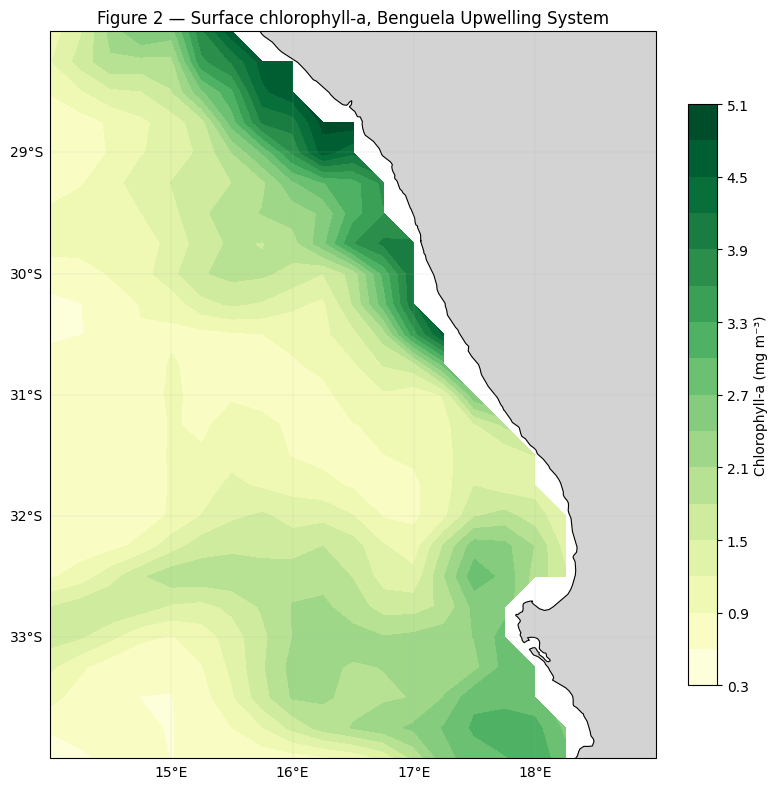

In [28]:
# ============================================================
# FIGURE 2 — Surface chlorophyll-a, Benguela
# ============================================================
fig = plt.figure(figsize=(11, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([14, 19, -34, -28], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)

cf = ax.contourf(chl.longitude, chl.latitude, chl,
                 levels=15, cmap="YlGn", transform=ccrs.PlateCarree())
cb = plt.colorbar(cf, ax=ax, pad=0.03, shrink=0.8)
cb.set_label("Chlorophyll-a (mg m⁻³)")

ax.set_title("Figure 2 — Surface chlorophyll-a, Benguela Upwelling System", fontsize=12)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4)
gl.top_labels = False; gl.right_labels = False
plt.tight_layout()
plt.savefig("fig2_benguela_chl.png", dpi=200, bbox_inches="tight")
plt.show()

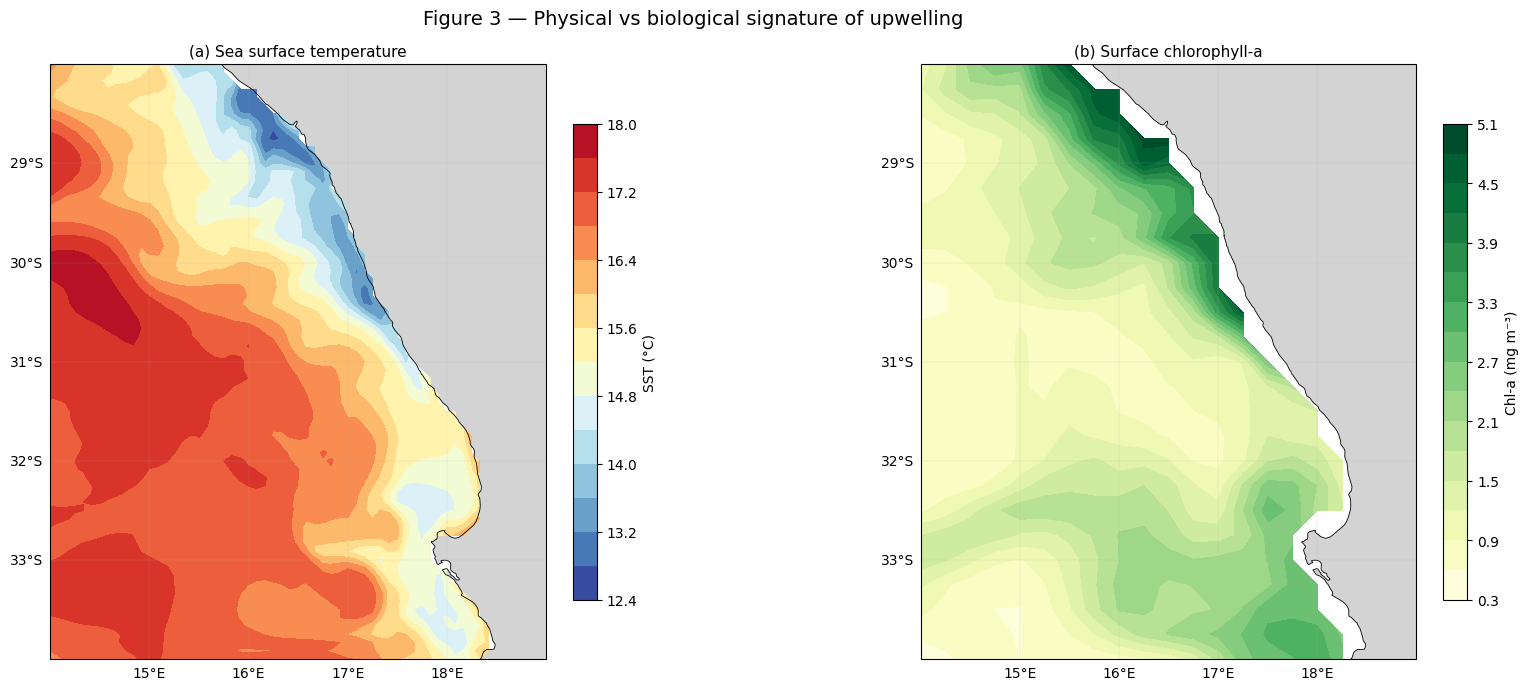

In [29]:
# ============================================================
# FIGURE 3 — SST vs chlorophyll side-by-side
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7),
                         subplot_kw={"projection": ccrs.PlateCarree()})
fig.suptitle("Figure 3 — Physical vs biological signature of upwelling", fontsize=14)

# --- Left: SST ---
ax = axes[0]
ax.set_extent([14, 19, -34, -28], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
cf1 = ax.contourf(sst.longitude, sst.latitude, sst,
                  levels=15, cmap="RdYlBu_r", transform=ccrs.PlateCarree())
plt.colorbar(cf1, ax=ax, pad=0.03, shrink=0.8).set_label("SST (°C)")
ax.set_title("(a) Sea surface temperature", fontsize=11)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4)
gl.top_labels = False; gl.right_labels = False

# --- Right: Chlorophyll ---
ax = axes[1]
ax.set_extent([14, 19, -34, -28], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
cf2 = ax.contourf(chl.longitude, chl.latitude, chl,
                  levels=15, cmap="YlGn", transform=ccrs.PlateCarree())
plt.colorbar(cf2, ax=ax, pad=0.03, shrink=0.8).set_label("Chl-a (mg m⁻³)")
ax.set_title("(b) Surface chlorophyll-a", fontsize=11)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4)
gl.top_labels = False; gl.right_labels = False

plt.tight_layout()
plt.savefig("fig3_sst_chl_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

In [35]:
# ============================================================
# FIGURE 4 — Seasonal SST and chlorophyll maps
# ============================================================
# Download monthly climatology for January (summer) and July (winter)
for month, tag in [(1, "jan"), (7, "jul")]:
    copernicusmarine.subset(
        dataset_id="cmems_mod_glo_phy-thetao_my_0.083deg_P1M-m",
        variables=["thetao"],
        minimum_longitude=bbox["lon_min"], maximum_longitude=bbox["lon_max"],
        minimum_latitude=bbox["lat_min"],  maximum_latitude=bbox["lat_max"],
        start_datetime=f"2023-{month:02d}-01",
        end_datetime=f"2023-{month:02d}-28",
        minimum_depth=0, maximum_depth=1,
        output_directory="cmems_data",
        output_filename=f"Benguela_sst_{tag}.nc",
    )

ds_jan = xr.open_dataset("cmems_data/Benguela_sst_jan.nc", engine="netcdf4")
ds_jul = xr.open_dataset("cmems_data/Benguela_sst_jul.nc", engine="netcdf4")

sst_jan = ds_jan["thetao"].isel(time=0, depth=0)
sst_jul = ds_jul["thetao"].isel(time=0, depth=0)

fig, axes = plt.subplots(1, 2, figsize=(18, 7),
                         subplot_kw={"projection": ccrs.PlateCarree()})
fig.suptitle("Figure 4 — Seasonal SST maps, Benguela (austral summer vs winter)", fontsize=14)

for ax, data, label in [
    (axes[0], sst_jan, "(a) January — austral summer"),
    (axes[1], sst_jul, "(b) July — austral winter"),
]:
    ax.set_extent([14, 19, -34, -28], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    cf = ax.contourf(data.longitude, data.latitude, data,
                     levels=15, cmap="RdYlBu_r", transform=ccrs.PlateCarree())
    plt.colorbar(cf, ax=ax, pad=0.03, shrink=0.8).set_label("SST (°C)")
    ax.set_title(label, fontsize=12)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4)
    gl.top_labels = False; gl.right_labels = False

plt.tight_layout()
plt.savefig("fig4_seasonal.png", dpi=200, bbox_inches="tight")
plt.show()

INFO - 2026-09-23T19:49:50Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register
INFO:copernicusmarine:Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username: zmabaso
Copernicus Marine password: ··········


DatasetNotFound: cmems_mod_glo_phy-thetao_my_0.083deg_P1M-m Please check that the dataset exists and the input datasetID is correct.

In [36]:
for month, tag in [(1, "jan"), (7, "jul")]:
    copernicusmarine.subset(
        dataset_id="cmems_mod_glo_phy-thetao_anfc_0.083deg_P1M-m",
        variables=["thetao"],
        minimum_longitude=bbox["lon_min"], maximum_longitude=bbox["lon_max"],
        minimum_latitude=bbox["lat_min"],  maximum_latitude=bbox["lat_max"],
        start_datetime=f"2023-{month:02d}-01",   # ← changed to 2023
        end_datetime=f"2023-{month:02d}-28",
        minimum_depth=0, maximum_depth=1,
        output_directory="cmems_data",
        output_filename=f"Benguela_sst_{tag}.nc",
    )

INFO - 2026-09-23T19:55:12Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register
INFO:copernicusmarine:Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username: zmabaso
Copernicus Marine password: ··········


INFO - 2026-09-23T19:55:29Z - Selected dataset version: "202406"
INFO:copernicusmarine:Selected dataset version: "202406"
INFO - 2026-09-23T19:55:29Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
WARNING - 2026-09-23T19:55:29Z - Some of your subset selection [0.0, 1.0] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 5727.9169921875]
INFO - 2026-09-23T19:55:33Z - Total size of the download: 30.72 KB.
INFO:copernicusmarine:Total size of the download: 30.72 KB.
INFO - 2026-09-23T19:55:33Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register
INFO:copernicusmarine:Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username: zmabaso
Copernicus Marine password: ··········


INFO - 2026-09-23T19:55:52Z - Selected dataset version: "202406"
INFO:copernicusmarine:Selected dataset version: "202406"
INFO - 2026-09-23T19:55:52Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
WARNING - 2026-09-23T19:55:52Z - Some of your subset selection [0.0, 1.0] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 5727.9169921875]
INFO - 2026-09-23T19:55:58Z - Total size of the download: 30.72 KB.
INFO:copernicusmarine:Total size of the download: 30.72 KB.


INFO - 2026-09-23T19:57:01Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register
INFO:copernicusmarine:Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username: zmabaso
Copernicus Marine password: ··········


INFO - 2026-09-23T19:57:18Z - Selected dataset version: "202311"
INFO:copernicusmarine:Selected dataset version: "202311"
INFO - 2026-09-23T19:57:18Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
WARNING - 2026-09-23T19:57:18Z - Some of your subset selection [0.0, 1.0] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 5727.9169921875]


  0%|          | [00:00<?]

INFO - 2026-09-23T19:57:27Z - Total size of the download: 256.97 KB.
INFO:copernicusmarine:Total size of the download: 256.97 KB.
INFO - 2026-09-23T19:57:27Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register
INFO:copernicusmarine:Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username: zmabaso
Copernicus Marine password: ··········


INFO - 2026-09-23T19:58:37Z - Selected dataset version: "202311"
INFO:copernicusmarine:Selected dataset version: "202311"
INFO - 2026-09-23T19:58:37Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
WARNING - 2026-09-23T19:58:37Z - Some of your subset selection [0.0, 1.0] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 5727.9169921875]


  0%|          | [00:00<?]

INFO - 2026-09-23T19:58:48Z - Total size of the download: 256.97 KB.
INFO:copernicusmarine:Total size of the download: 256.97 KB.


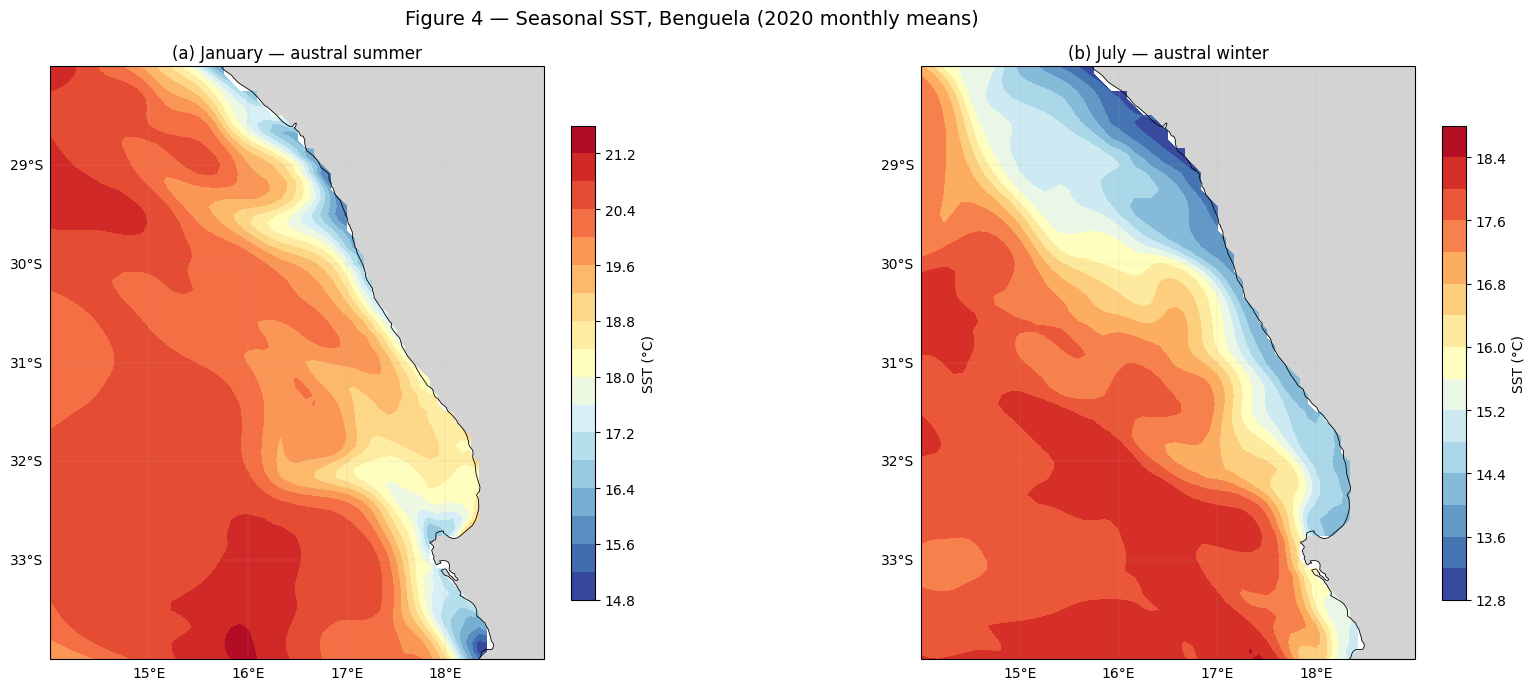

In [37]:
# ============================================================
# FIGURE 4 — Seasonal SST maps (January vs July)
# Using the multi-year reanalysis dataset (1993–2021)
# ============================================================
for month, tag in [(1, "jan"), (7, "jul")]:
    copernicusmarine.subset(
        dataset_id="cmems_mod_glo_phy_my_0.083deg_P1D-m",   # daily reanalysis
        variables=["thetao"],
        minimum_longitude=bbox["lon_min"], maximum_longitude=bbox["lon_max"],
        minimum_latitude=bbox["lat_min"],  maximum_latitude=bbox["lat_max"],
        start_datetime=f"2020-{month:02d}-01",
        end_datetime=f"2020-{month:02d}-28",
        minimum_depth=0, maximum_depth=1,
        output_directory="cmems_data",
        output_filename=f"Benguela_sst_{tag}_2020.nc",
    )

# Load and average over time to get a monthly mean
ds_jan = xr.open_dataset("cmems_data/Benguela_sst_jan_2020.nc", engine="netcdf4")
ds_jul = xr.open_dataset("cmems_data/Benguela_sst_jul_2020.nc", engine="netcdf4")

sst_jan = ds_jan["thetao"].isel(depth=0).mean(dim="time")
sst_jul = ds_jul["thetao"].isel(depth=0).mean(dim="time")

fig, axes = plt.subplots(1, 2, figsize=(18, 7),
                         subplot_kw={"projection": ccrs.PlateCarree()})
fig.suptitle("Figure 4 — Seasonal SST, Benguela (2020 monthly means)", fontsize=14)

for ax, data, label in [
    (axes[0], sst_jan, "(a) January — austral summer"),
    (axes[1], sst_jul, "(b) July — austral winter"),
]:
    ax.set_extent([14, 19, -34, -28], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    cf = ax.contourf(data.longitude, data.latitude, data,
                     levels=15, cmap="RdYlBu_r", transform=ccrs.PlateCarree())
    plt.colorbar(cf, ax=ax, pad=0.03, shrink=0.8).set_label("SST (°C)")
    ax.set_title(label, fontsize=12)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4)
    gl.top_labels = False; gl.right_labels = False

plt.tight_layout()
plt.savefig("fig4_seasonal.png", dpi=200, bbox_inches="tight")
plt.show()

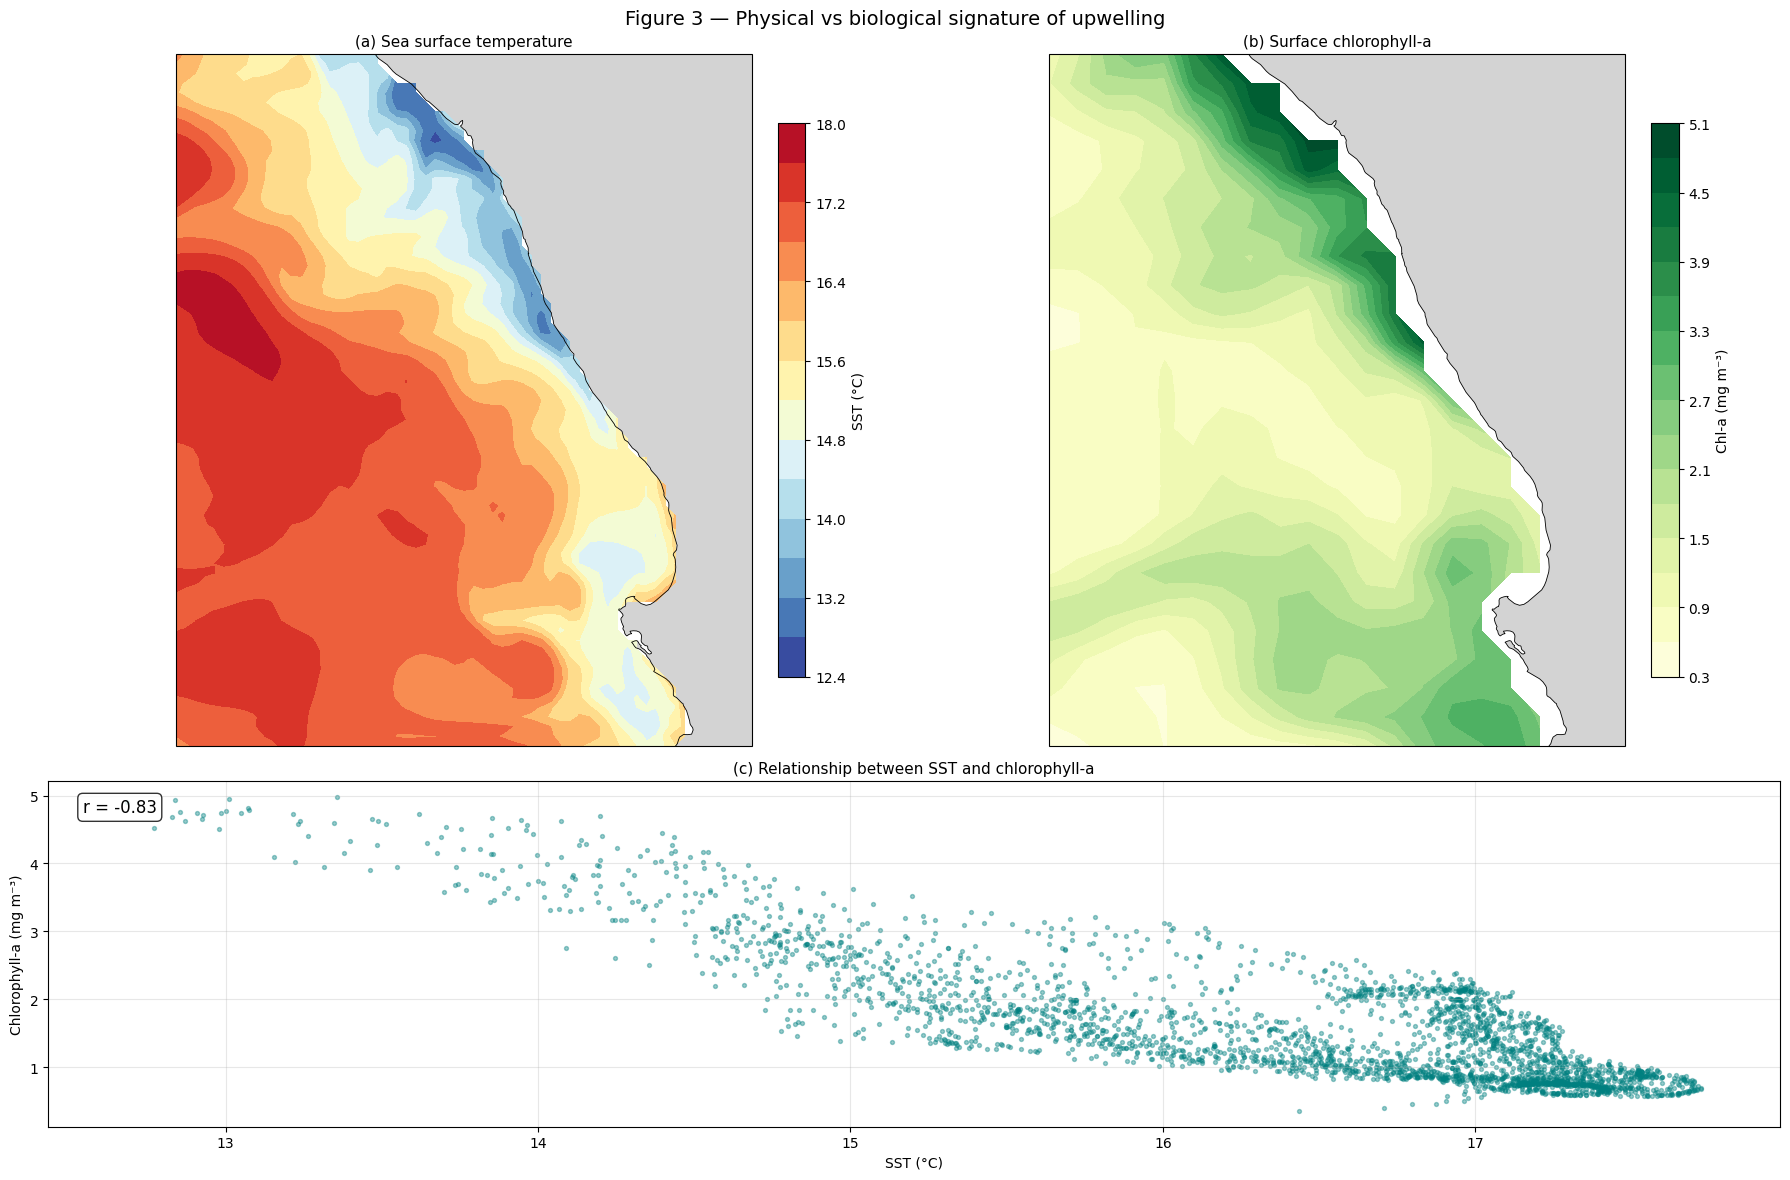

In [39]:
# ============================================================
# FIGURE 3 (improved) — SST, chlorophyll, and their relationship
# ============================================================
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1])

# --- Top-left: SST map ---
ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
ax1.set_extent([14, 19, -34, -28], crs=ccrs.PlateCarree())
ax1.add_feature(cfeature.LAND, facecolor="lightgray")
ax1.add_feature(cfeature.COASTLINE, linewidth=0.6)
cf1 = ax1.contourf(sst.longitude, sst.latitude, sst,
                   levels=15, cmap="RdYlBu_r", transform=ccrs.PlateCarree())
plt.colorbar(cf1, ax=ax1, pad=0.03, shrink=0.8).set_label("SST (°C)")
ax1.set_title("(a) Sea surface temperature", fontsize=11)

# --- Top-right: chlorophyll map ---
ax2 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
ax2.set_extent([14, 19, -34, -28], crs=ccrs.PlateCarree())
ax2.add_feature(cfeature.LAND, facecolor="lightgray")
ax2.add_feature(cfeature.COASTLINE, linewidth=0.6)
cf2 = ax2.contourf(chl.longitude, chl.latitude, chl,
                   levels=15, cmap="YlGn", transform=ccrs.PlateCarree())
plt.colorbar(cf2, ax=ax2, pad=0.03, shrink=0.8).set_label("Chl-a (mg m⁻³)")
ax2.set_title("(b) Surface chlorophyll-a", fontsize=11)

# --- Bottom: scatter plot ---
ax3 = fig.add_subplot(gs[1, :])
# Regrid chlorophyll onto the SST grid for pixel-wise comparison
chl_on_sst = chl.interp(longitude=sst.longitude, latitude=sst.latitude)
sst_flat = sst.values.flatten()
chl_flat = chl_on_sst.values.flatten()
mask = np.isfinite(sst_flat) & np.isfinite(chl_flat)

ax3.scatter(sst_flat[mask], chl_flat[mask], s=8, alpha=0.4, color="teal")
ax3.set_xlabel("SST (°C)")
ax3.set_ylabel("Chlorophyll-a (mg m⁻³)")
ax3.set_title("(c) Relationship between SST and chlorophyll-a", fontsize=11)
ax3.grid(alpha=0.3)

# Optional: correlation coefficient
r = np.corrcoef(sst_flat[mask], chl_flat[mask])[0, 1]
ax3.text(0.02, 0.95, f"r = {r:.2f}", transform=ax3.transAxes,
         fontsize=12, va="top",
         bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

fig.suptitle("Figure 3 — Physical vs biological signature of upwelling", fontsize=14)
plt.tight_layout()
plt.savefig("fig3_sst_chl_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

Copernicus Marine username: zmabaso
Copernicus Marine password: ··········


INFO - 2026-09-23T20:10:04Z - Checking if credentials are valid.
INFO:copernicusmarine:Checking if credentials are valid.
INFO - 2026-09-23T20:10:04Z - Valid credentials from input username and password.
INFO:copernicusmarine:Valid credentials from input username and password.


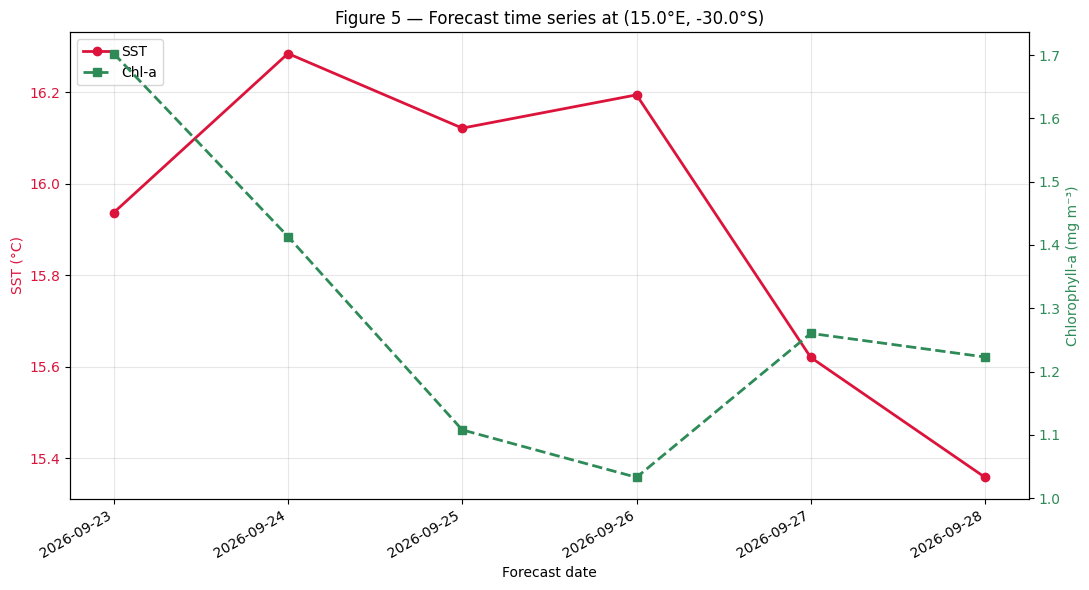

In [40]:
# ============================================================
# FIGURE 5 — Forecast time-series at a coastal point
# ============================================================
from datetime import datetime, timedelta, timezone
import copernicusmarine
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import os
from getpass import getpass

# --- Login ---
os.environ["CM_USERNAME"] = input("Copernicus Marine username: ")
os.environ["CM_PASSWORD"] = getpass("Copernicus Marine password: ")
copernicusmarine.login(
    username=os.environ["CM_USERNAME"],
    password=os.environ["CM_PASSWORD"],
    check_credentials_valid=True,
)

# --- Point of interest (coastal Benguela) ---
lon_pt, lat_pt = 15.0, -30.0

# --- Load the already-downloaded forecast data ---
ds = xr.merge([
    xr.open_dataset("cmems_data/Benguela_thetao_forecast.nc", engine="netcdf4"),
    xr.open_dataset("cmems_data/Benguela_so_forecast.nc", engine="netcdf4"),
    xr.open_dataset("cmems_data/Benguela_uo_vo_forecast.nc", engine="netcdf4"),
])
ds_chl = xr.open_dataset("cmems_data/Benguela_chl_forecast.nc", engine="netcdf4")

# --- Extract time-series at the point ---
ts_sst = ds["thetao"].isel(depth=0).sel(longitude=lon_pt, latitude=lat_pt, method="nearest")
ts_chl = ds_chl["chl"].isel(depth=0).sel(longitude=lon_pt, latitude=lat_pt, method="nearest")

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(11, 6))

color_sst = "crimson"
ax1.set_xlabel("Forecast date")
ax1.set_ylabel("SST (°C)", color=color_sst)
ax1.plot(ts_sst.time, ts_sst, marker="o", color=color_sst, linewidth=2, label="SST")
ax1.tick_params(axis="y", labelcolor=color_sst)

ax2 = ax1.twinx()
color_chl = "seagreen"
ax2.set_ylabel("Chlorophyll-a (mg m⁻³)", color=color_chl)
ax2.plot(ts_chl.time, ts_chl, marker="s", color=color_chl, linewidth=2,
         linestyle="--", label="Chl-a")
ax2.tick_params(axis="y", labelcolor=color_chl)

ax1.set_title(f"Figure 5 — Forecast time series at ({lon_pt}°E, {lat_pt}°S)")
ax1.grid(alpha=0.3)
fig.autofmt_xdate(rotation=30)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.savefig("fig5_timeseries.png", dpi=200, bbox_inches="tight")
plt.show()

In [41]:

# --- Southern Ocean bounding box ---
bbox = {"lon_min": -180.0, "lon_max": 180.0, "lat_min": -80.0, "lat_max": -50.0}

# --- Download February monthly means for 2023, 2024, 2025 ---
for year in [2023, 2024, 2025]:
    copernicusmarine.subset(
        dataset_id="cmems_mod_glo_phy_my_0.083deg_P1D-m",  # multi-year reanalysis
        variables=["thetao"],
        minimum_longitude=bbox["lon_min"], maximum_longitude=bbox["lon_max"],
        minimum_latitude=bbox["lat_min"],  maximum_latitude=bbox["lat_max"],
        start_datetime=f"{year}-02-01",
        end_datetime=f"{year}-02-28",
        minimum_depth=0, maximum_depth=1,
        output_directory="cmems_data",
        output_filename=f"SouthernOcean_SST_Feb{year}.nc",
    )
print("Downloads complete.")

INFO - 2026-09-23T20:34:21Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register
INFO:copernicusmarine:Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username: zmabaso
Copernicus Marine password: ··········


INFO - 2026-09-23T20:34:47Z - Selected dataset version: "202311"
INFO:copernicusmarine:Selected dataset version: "202311"
INFO - 2026-09-23T20:34:47Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
WARNING - 2026-09-23T20:34:47Z - Some of your subset selection [0.0, 1.0] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 5727.9169921875]


  0%|          | [00:00<?]

INFO - 2026-09-23T20:35:02Z - Total size of the download: 83.35 MB.
INFO:copernicusmarine:Total size of the download: 83.35 MB.
INFO - 2026-09-23T20:35:02Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register
INFO:copernicusmarine:Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


...

Copernicus Marine username: zmabaso
Copernicus Marine password: ··········


INFO - 2026-09-23T20:35:58Z - Selected dataset version: "202311"
INFO:copernicusmarine:Selected dataset version: "202311"
INFO - 2026-09-23T20:35:58Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
WARNING - 2026-09-23T20:35:58Z - Some of your subset selection [0.0, 1.0] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 5727.9169921875]


  0%|          | [00:00<?]

INFO - 2026-09-23T20:36:11Z - Total size of the download: 83.35 MB.
INFO:copernicusmarine:Total size of the download: 83.35 MB.


Downloads complete.
